<a href="https://colab.research.google.com/github/maumandisaya/Mini-Project/blob/main/Copy_of_Projek_Datsa_Branch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset yang digunakan berasal dari kaggle : https://www.kaggle.com/datasets/indraputra21/used-car-listings-in-indonesia/data?select=used_car.csv

#Install kagglehub dan load dataset
Wajib di eksekusi!!

In [3]:
#  kalo kode dibawah line error, run line ini lagi
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Download latest version
path = kagglehub.dataset_download("indraputra21/used-car-listings-in-indonesia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'used-car-listings-in-indonesia' dataset.
Path to dataset files: /kaggle/input/used-car-listings-in-indonesia


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/used-car-listings-in-indonesia/used_car.csv")
display(df.head())
df.shape

,car name,brand,year,mileage (km),location,transmission,plate type,rear camera,sun roof,auto retract mirror,electric parking brake,map navigator,vehicle stability control,keyless push start,sports mode,360 camera view,power sliding door,auto cruise control,price (Rp),instalment (Rp|Monthly)
0,AYLA X 1.2,Daihatsu,2018,10.508,Jakarta Utara,Manual,even plate,0,0,0,0,0,0,0,0,0,0,0,101000000,2060000
1,AGYA TRD SPORTIVO 1.0,Toyota,2015,112.888,Bogor,Manual,even plate,0,0,0,0,0,0,0,0,0,0,0,82000000,1670000
2,X-TRAIL 2.5,Nissan,2015,118.429,Surabaya,Automatic,odd plate,0,0,0,0,0,0,1,0,1,0,0,169000000,3440000
3,YARIS S TRD 1.5,Toyota,2020,15.945,Tangerang Selatan,Automatic,odd plate,0,0,0,0,0,0,0,0,0,0,0,218000000,4440000
4,AGYA G 1.2,Toyota,2019,30.404,Jakarta Barat,Manual,odd plate,0,0,0,0,0,0,0,0,0,0,0,117000000,2380000


(609, 20)

In [5]:
print(f'''
Jenis-jenis mobil yang dijual :
{df['car name'].unique()}

komposisi moil matic dan manual :
{df['transmission'].unique()}

komposisi tipe plat "
{df["plate type"].unique()}


''')


Jenis-jenis mobil yang dijual :
['AYLA X 1.2' 'AGYA TRD SPORTIVO 1.0' 'X-TRAIL 2.5' 'YARIS S TRD 1.5'
 'AGYA G 1.2' 'AVANZA G 1.3' 'AVANZA G 1.5' 'OUTLANDER SPORT PX 2.0'
 'BRIO SATYA E 1.2' 'HR-V S 1.5' 'AGYA G TRD 1.2' 'AYLA R 1.2'
 'AYLA R DLX 1.2' 'ALMAZ LT LUX 1.5' 'TERIOS TX 1.5' 'MOBILIO E 1.5'
 'ERTIGA GL 1.5' 'CR-V TURBO 1.5' 'CONFERO 2WD 1.5' 'LIVINA VL 1.5'
 'CALYA G 1.2' 'TERIOS R 1.5' 'XPANDER ULTIMATE 1.5' 'AYLA X 1.0'
 'HR-V E 1.5' 'OUTLANDER SPORT GLS 2.0' 'HR-V SE 1.5' 'ALMAZ S+T 1.5'
 'IGNIS GL 1.2' 'KIJANG INNOVA REBORN G 2.0' 'MOBILIO RS 1.5'
 'KIJANG INNOVA V 2.0' 'KIJANG INNOVA G 2.0' 'AGYA GR SPORT 1.2'
 'TERIOS X DLX 1.5' 'BRIO RS 1.2' 'FORTUNER VRZ 2.4' 'CX-5 ELITE 2.5'
 'GRAND LIVINA XV 1.5' 'AGYA G 1.0' 'IGNIS GX 1.2' 'CORTEZ C T LUX 1.5'
 'ALMAZ RS LT LUX + SC CVT 1.5' 'CONFERO S 1.5' 'ALMAZ L TURBO 1.5'
 'KIJANG INNOVA REBORN VENTURER GASOLINE 2.0' 'BALENO HATCHBACK 1.4'
 'TERIOS X 1.5' 'ALMAZ LT LUX + SC CVT 1.5' 'CITY RS HATCHBACK 1.5'
 'AYLA X ELEGANT 1

In [6]:
list_car = df['car name'].value_counts()
list_car

,count
car name,
BRIO SATYA E 1.2,48
XPANDER ULTIMATE 1.5,38
CALYA G 1.2,21
AYLA R 1.2,19
RUSH S TRD SPORTIVO 1.5,18
...,...
3 20I (CKD) 2.0,1
BRIO E 1.3,1
FREED S 1.5,1


# Pemeriksaan awal data

Periksa tipe data, nilai yang hilang, dan ringkasan statistik dari dataset.


In [7]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics (Numeric):")
print(df.describe())

Data Types:
car name                      object
brand                         object
year                           int64
mileage (km)                 float64
location                      object
transmission                  object
plate type                    object
rear camera                    int64
sun roof                       int64
auto retract mirror            int64
electric parking brake         int64
map navigator                  int64
vehicle stability control      int64
keyless push start             int64
sports mode                    int64
360 camera view                int64
power sliding door             int64
auto cruise control            int64
price (Rp)                     int64
instalment (Rp|Monthly)        int64
dtype: object

Missing Values:
car name                     0
brand                        0
year                         0
mileage (km)                 0
location                     0
transmission                 0
plate type                   0


# Analisis variabel kategorikal


Analisis distribusi dan hubungan antara variabel kategorikal ('plate_type' dan 'transmission') dengan 'price_rp'.


Average Price by Transmission Type:
transmission
Automatic    2.005247e+08
Manual       1.349663e+08
Name: price (Rp), dtype: float64

Average Price by Plate Type:
plate type
even plate    1.875436e+08
odd plate     1.778889e+08
Name: price (Rp), dtype: float64


<Figure size 1200x600 with 0 Axes>

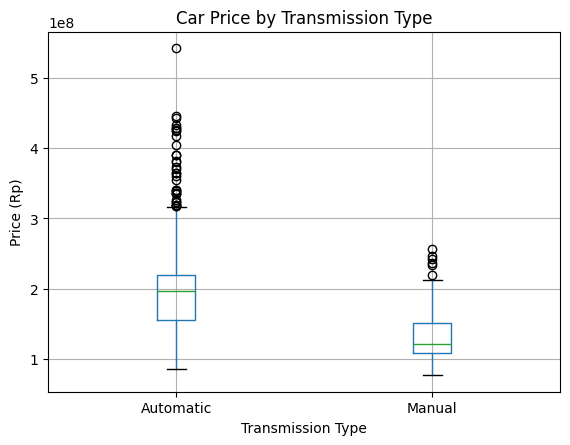

<Figure size 800x600 with 0 Axes>

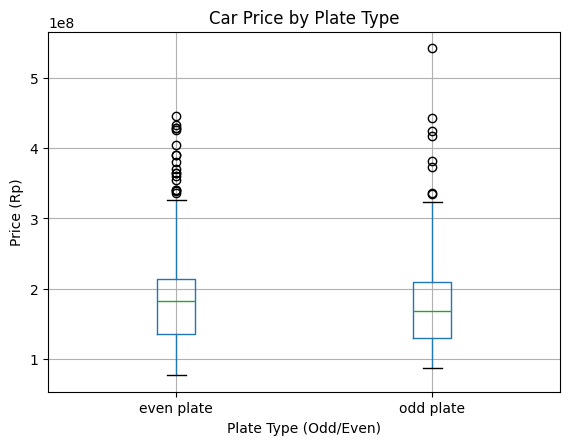

In [8]:
avg_by_transmission = df.groupby('transmission')['price (Rp)'].mean()
print("Average Price by Transmission Type:")
print(avg_by_transmission)

avg_by_plate = df.groupby('plate type')['price (Rp)'].mean()
print("\nAverage Price by Plate Type:")
print(avg_by_plate)

plt.figure(figsize=(12, 6))
df.boxplot(column='price (Rp)', by='transmission')
plt.xlabel('Transmission Type')
plt.ylabel('Price (Rp)')
plt.title('Car Price by Transmission Type')
plt.suptitle('') # Suppress default title
plt.show()

plt.figure(figsize=(8, 6))
df.boxplot(column='price (Rp)', by='plate type')
plt.xlabel('Plate Type (Odd/Even)')
plt.ylabel('Price (Rp)')
plt.title('Car Price by Plate Type')
plt.suptitle('') # Suppress default title
plt.show()

#Remove Outliers per Group


In [11]:
df_clean_transmission = pd.DataFrame()

for transmission in df['transmission'].unique():
    transmission_group = df[df['transmission'] == transmission]

    Q1 = transmission_group['price (Rp)'].quantile(0.25)
    Q3 = transmission_group['price (Rp)'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter data untuk menghapus outlier dalam grup bulan ini
    filtered_transmission_group = transmission_group[(transmission_group['price (Rp)'] >= lower_bound) & (transmission_group['price (Rp)'] <= upper_bound)]

    df_clean_transmission = pd.concat([df_clean_transmission, filtered_transmission_group])

print(f"Bentuk DataFrame asli: {df.shape}")
print(f"Bentuk DataFrame setelah menghapus outlier per transmisi: {df_clean_transmission.shape}")

Bentuk DataFrame asli: (609, 20)
Bentuk DataFrame setelah menghapus outlier per transmisi: (570, 20)


In [12]:
df_clean_plate = pd.DataFrame()

for plate in df['plate type'].unique():
    plate_group = df[df['plate type'] == plate]

    Q1 = plate_group['price (Rp)'].quantile(0.25)
    Q3 = plate_group['price (Rp)'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter data to remove outliers within this tariff group
    filtered_plate_group = plate_group[(plate_group['price (Rp)'] >= lower_bound) & (plate_group['price (Rp)'] <= upper_bound)]

    df_clean_plate = pd.concat([df_clean_plate, filtered_plate_group])

print(f"Bentuk DataFrame asli: {df.shape}")
print(f"Bentuk DataFrame setelah menghapus outlier per tipe plat: {df_clean_plate.shape}")

Bentuk DataFrame asli: (609, 20)
Bentuk DataFrame setelah menghapus outlier per tipe plat: (583, 20)


#Visualisasi Box Plot


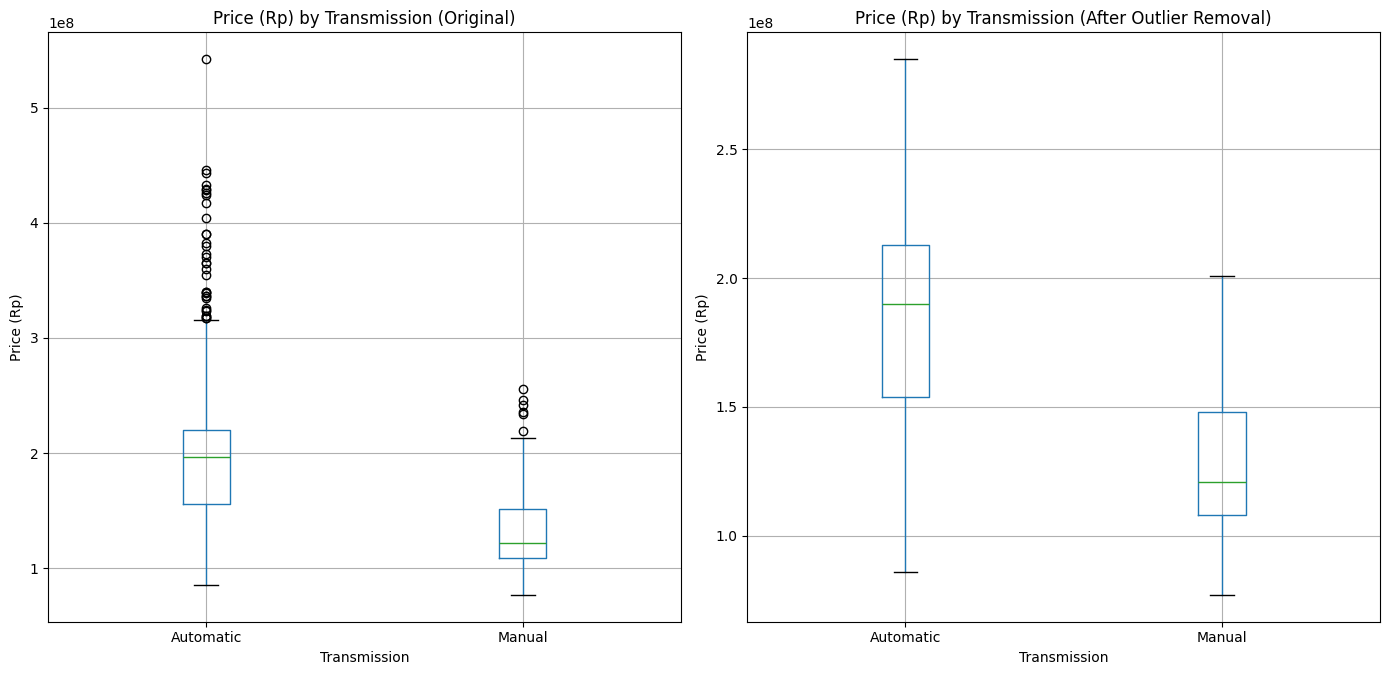

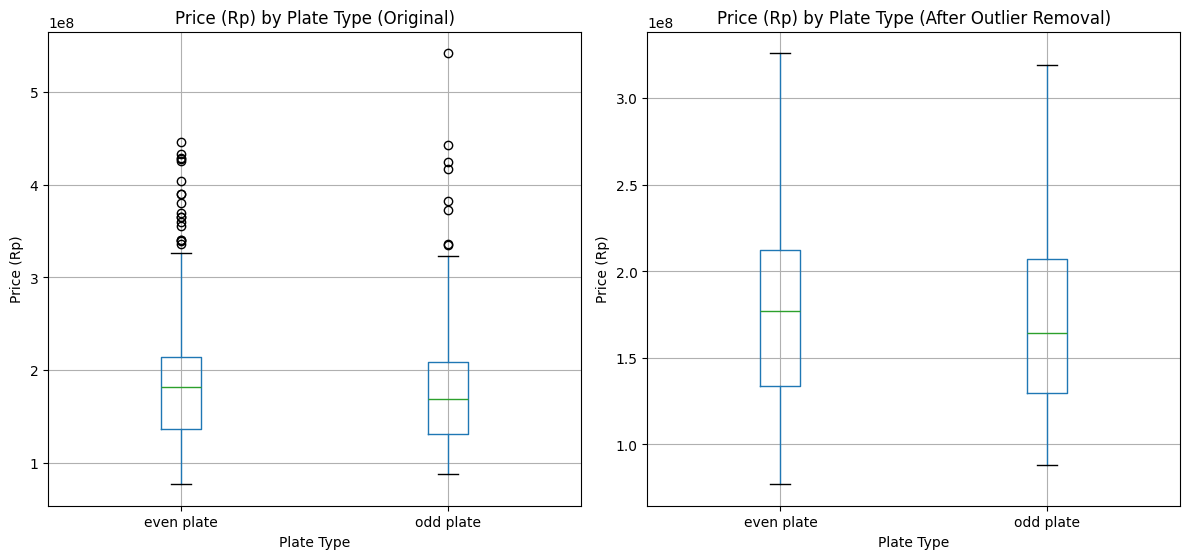

In [13]:
import matplotlib.pyplot as plt

# Visualize 'price (Rp)' distribution by 'transmission' (Before and After Outlier Removal)
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
df.boxplot(column='price (Rp)', by='transmission', ax=plt.gca())
plt.xlabel('Transmission')
plt.ylabel('Price (Rp)')
plt.title('Price (Rp) by Transmission (Original)')
plt.suptitle('')
print()

plt.subplot(1, 2, 2)
df_clean_transmission.boxplot(column='price (Rp)', by='transmission', ax=plt.gca(), showfliers=False) # Modified: Added showfliers=False
plt.xlabel('Transmission')
plt.ylabel('Price (Rp)')
plt.title('Price (Rp) by Transmission (After Outlier Removal)')
plt.suptitle('')
plt.tight_layout()
plt.show()
print()

# Visualize 'price (Rp)' distribution by 'plate type' (Before and After Outlier Removal)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df.boxplot(column='price (Rp)', by='plate type', ax=plt.gca())
plt.xlabel('Plate Type')
plt.ylabel('Price (Rp)')
plt.title('Price (Rp) by Plate Type (Original)')
plt.suptitle('')
print()

plt.subplot(1, 2, 2)
df_clean_plate.boxplot(column='price (Rp)', by='plate type', ax=plt.gca(), showfliers=False) # Modified: Added showfliers=False
plt.xlabel('Plate Type')
plt.ylabel('Price (Rp)')
plt.title('Price (Rp) by Plate Type (After Outlier Removal)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Membuat DataFrame Bersih Gabungan


Untuk mendapatkan DataFrame yang bersih dari pencilan berdasarkan kedua kriteria ('transmission' dan 'plate type'), kita akan mengambil irisan (intersection) dari indeks baris yang tersisa setelah penghapusan outlier per transmisi dan per tipe plat..


In [14]:
common_indices = df_clean_transmission.index.intersection(df_clean_plate.index)
df_clean_combined = df.loc[common_indices]
df_clean_combined = df_clean_combined.reset_index(drop = True)
df_clean_combined.drop('instalment (Rp|Monthly)', axis = 1, inplace = True)
#print(f"Bentuk DataFrame asli: {df.shape}")
#print(f"Bentuk DataFrame setelah menghapus outlier per transmisi DAN per tipe plat: {df_clean_combined.shape}")

In [15]:
df_clean_combined.columns

Index(['car name', 'brand', 'year', 'mileage (km)', 'location', 'transmission',
       'plate type', 'rear camera', 'sun roof', 'auto retract mirror',
       'electric parking brake', 'map navigator', 'vehicle stability control',
       'keyless push start', 'sports mode', '360 camera view',
       'power sliding door', 'auto cruise control', 'price (Rp)'],
      dtype='object')

In [16]:
df_clean_combined

,car name,brand,year,mileage (km),location,transmission,plate type,rear camera,sun roof,auto retract mirror,electric parking brake,map navigator,vehicle stability control,keyless push start,sports mode,360 camera view,power sliding door,auto cruise control,price (Rp)
0,AYLA X 1.2,Daihatsu,2018,10.508,Jakarta Utara,Manual,even plate,0,0,0,0,0,0,0,0,0,0,0,101000000
1,AGYA TRD SPORTIVO 1.0,Toyota,2015,112.888,Bogor,Manual,even plate,0,0,0,0,0,0,0,0,0,0,0,82000000
2,AGYA G 1.2,Toyota,2019,30.404,Jakarta Barat,Manual,odd plate,0,0,0,0,0,0,0,0,0,0,0,117000000
3,AVANZA G 1.3,Toyota,2021,17.306,Tangerang Selatan,Manual,even plate,0,0,1,0,0,0,0,0,0,0,0,180000000
4,AVANZA G 1.5,Toyota,2022,12.211,Surabaya,Manual,even plate,0,0,1,0,0,0,0,0,0,0,0,211000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,AGYA G 1.2,Toyota,2018,60.588,Bogor,Automatic,odd plate,0,0,0,0,0,0,0,0,0,0,0,122000000
566,AVANZA VELOZ 1.5,Toyota,2020,50.137,Bogor,Automatic,odd plate,1,0,1,0,0,0,0,0,0,0,0,204000000
567,RAIZE GR SPORT TSS 1.0,Toyota,2021,32.288,Bogor,Automatic,odd plate,0,0,1,0,0,0,0,0,0,0,0,234000000
568,AGYA G TRD 1.2,Toyota,2019,26.474,Jakarta Utara,Automatic,odd plate,0,0,0,0,0,0,0,0,0,0,0,136000000


#Analisis Variable Numerik

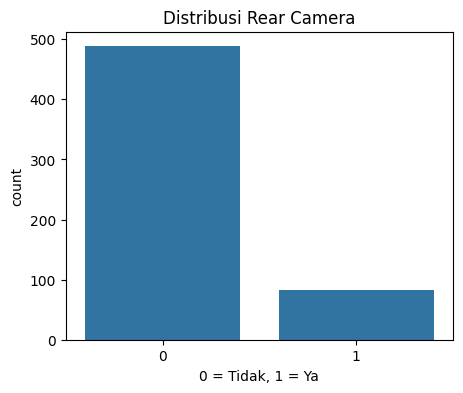

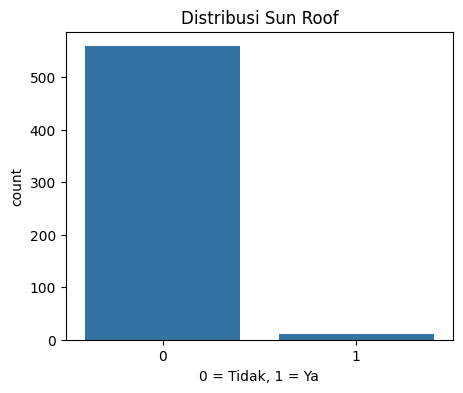

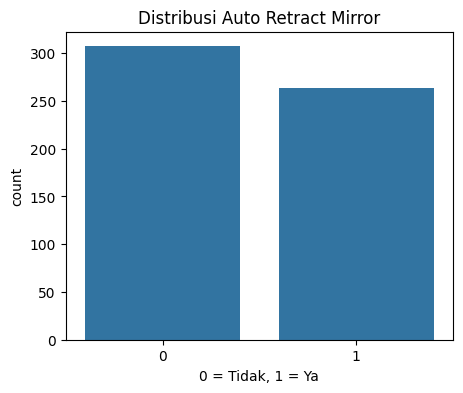

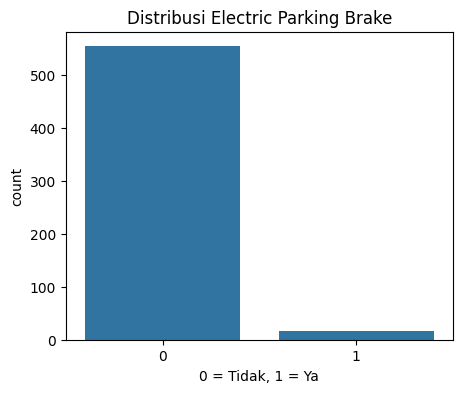

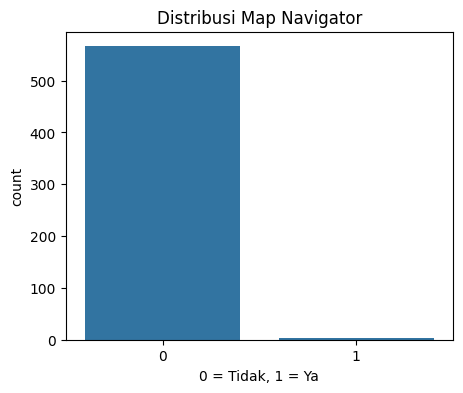

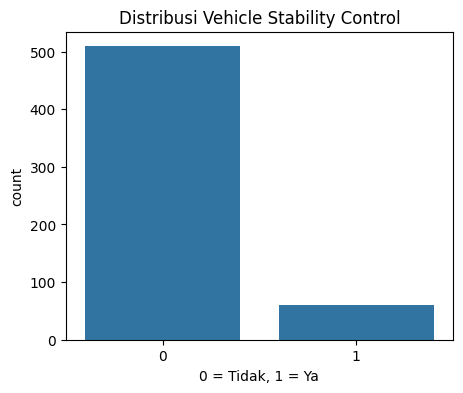

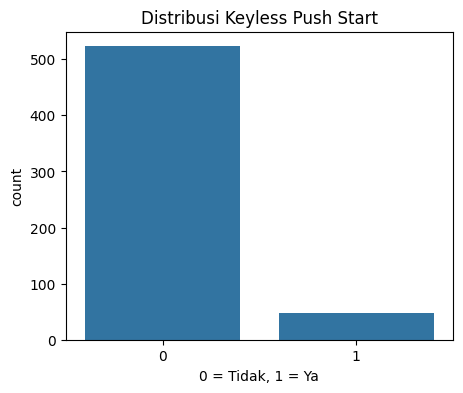

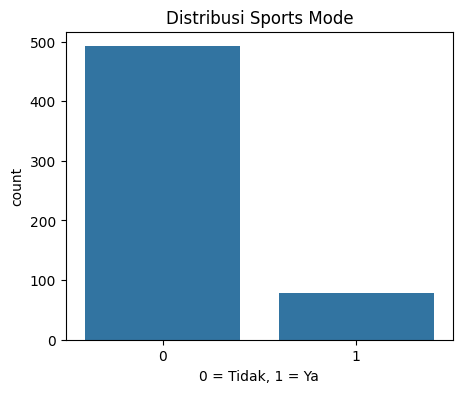

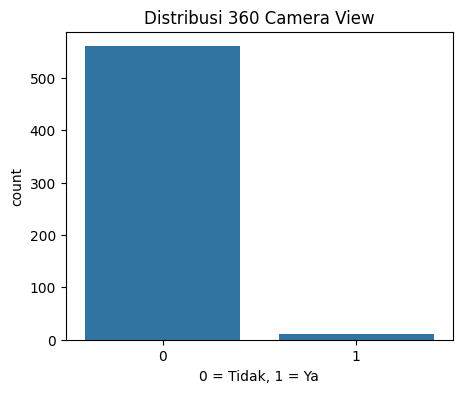

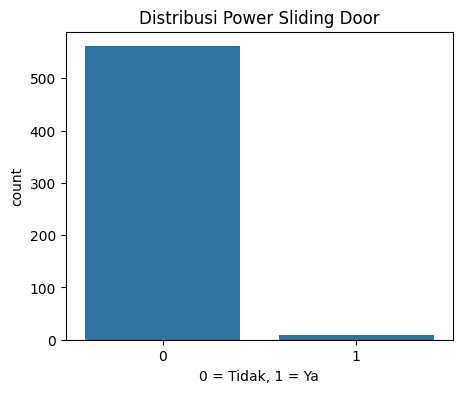

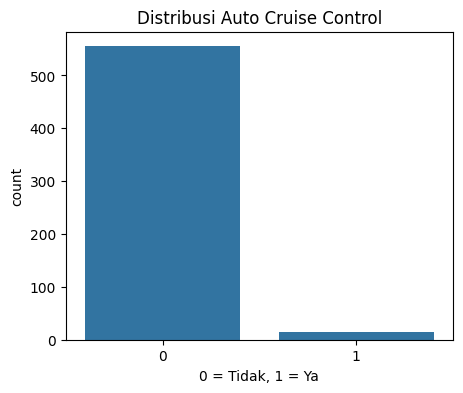

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

binary_cols = ['rear camera',	'sun roof',	'auto retract mirror',	'electric parking brake',	'map navigator',	'vehicle stability control',	'keyless push start',	'sports mode',	'360 camera view',	'power sliding door',	'auto cruise control']

for col in binary_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=df_clean_combined[col])
    plt.title(f"Distribusi {col.replace('_',' ').title()}")
    plt.xlabel("0 = Tidak, 1 = Ya")
    plt.show()
    print()


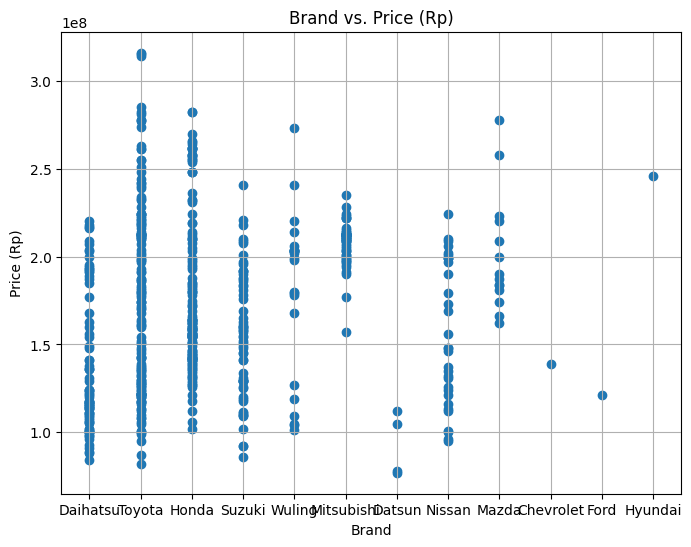

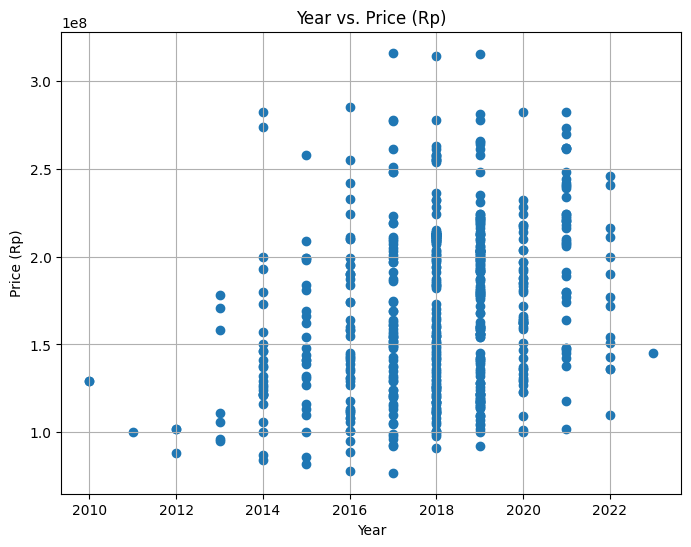

In [18]:
import matplotlib.pyplot as plt

numerical_cols = ['brand', 'year']
target_col = 'price (Rp)'

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    plt.scatter(df_clean_combined[col], df_clean_combined[target_col])
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel('Price (Rp)')
    plt.title(f'{col.replace("_", " ").title()} vs. Price (Rp)')
    plt.grid(True)
    plt.show()

# Analisis korelasi

Hitung dan visualisasikan korelasi antar variabel numerik.


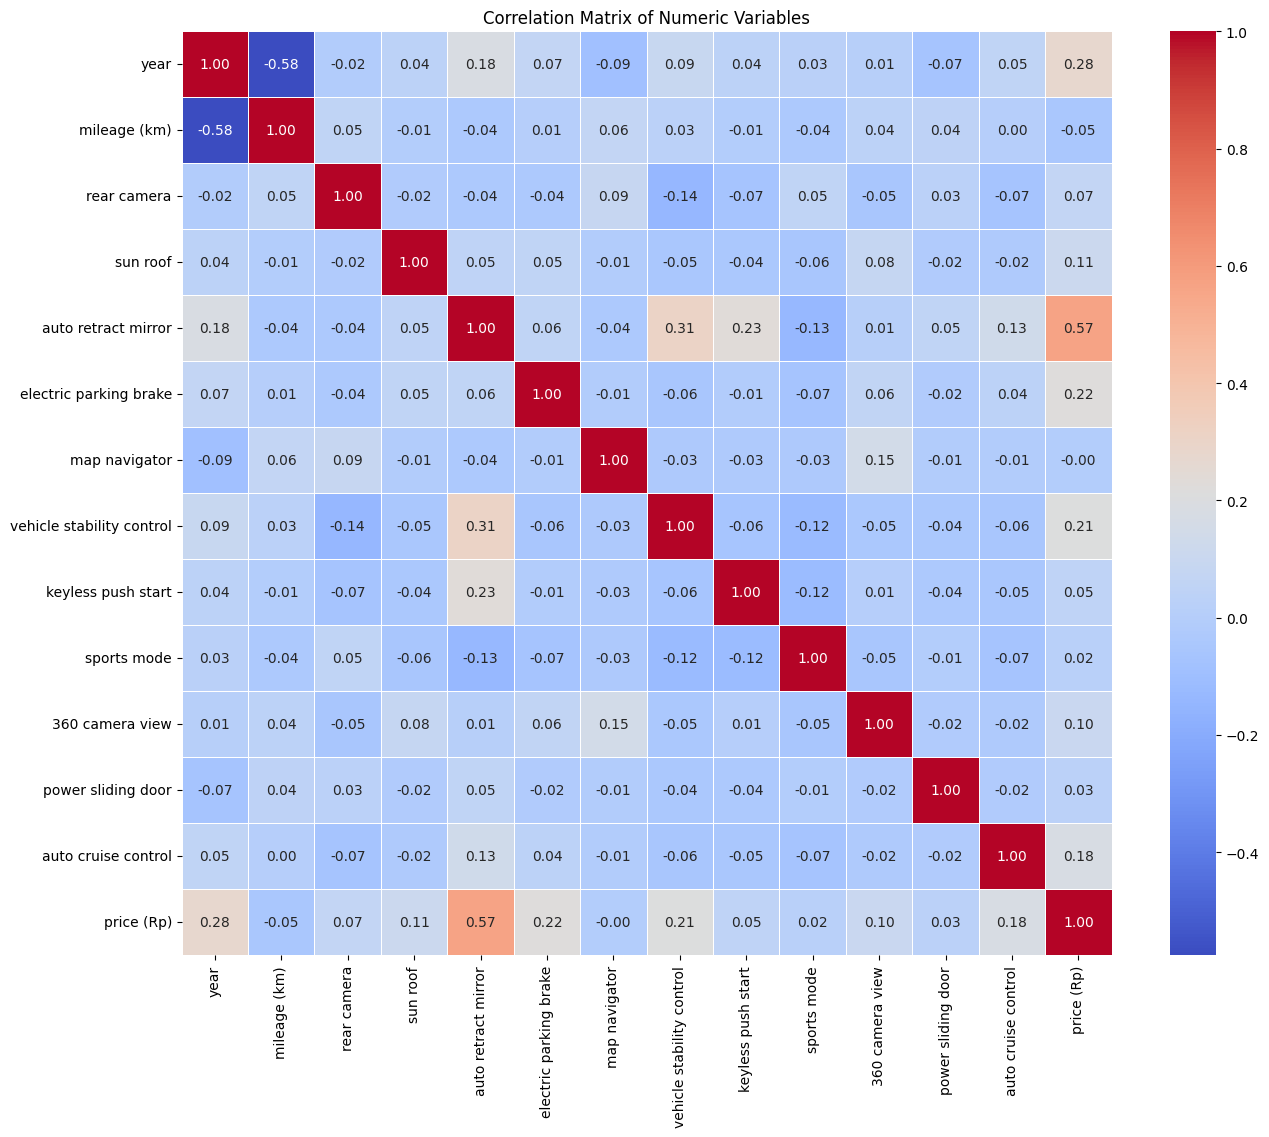

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df_clean_combined.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Visualize the correlation matrix
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

#Melakukan encoding pada data kategorik

Pada langkah ini akan diambil kolom yang entrinya data kategorik agar dapat di ubah \(encoding\) menjadi bentuk numerik

In [20]:
df_clean_combined

,car name,brand,year,mileage (km),location,transmission,plate type,rear camera,sun roof,auto retract mirror,electric parking brake,map navigator,vehicle stability control,keyless push start,sports mode,360 camera view,power sliding door,auto cruise control,price (Rp)
0,AYLA X 1.2,Daihatsu,2018,10.508,Jakarta Utara,Manual,even plate,0,0,0,0,0,0,0,0,0,0,0,101000000
1,AGYA TRD SPORTIVO 1.0,Toyota,2015,112.888,Bogor,Manual,even plate,0,0,0,0,0,0,0,0,0,0,0,82000000
2,AGYA G 1.2,Toyota,2019,30.404,Jakarta Barat,Manual,odd plate,0,0,0,0,0,0,0,0,0,0,0,117000000
3,AVANZA G 1.3,Toyota,2021,17.306,Tangerang Selatan,Manual,even plate,0,0,1,0,0,0,0,0,0,0,0,180000000
4,AVANZA G 1.5,Toyota,2022,12.211,Surabaya,Manual,even plate,0,0,1,0,0,0,0,0,0,0,0,211000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,AGYA G 1.2,Toyota,2018,60.588,Bogor,Automatic,odd plate,0,0,0,0,0,0,0,0,0,0,0,122000000
566,AVANZA VELOZ 1.5,Toyota,2020,50.137,Bogor,Automatic,odd plate,1,0,1,0,0,0,0,0,0,0,0,204000000
567,RAIZE GR SPORT TSS 1.0,Toyota,2021,32.288,Bogor,Automatic,odd plate,0,0,1,0,0,0,0,0,0,0,0,234000000
568,AGYA G TRD 1.2,Toyota,2019,26.474,Jakarta Utara,Automatic,odd plate,0,0,0,0,0,0,0,0,0,0,0,136000000


In [42]:
data_copy = df_clean_combined.copy()
data_copy['car name'] = data_copy['brand'] + " " + data_copy['car name']
data_copy.drop('brand', axis = 1, inplace = True)

In [43]:
dataset_cadangan = data_copy.copy()

Import BinaryEncoders dari category_encoders kemudian ubah entri menggunakan method fit_transform()

In [44]:
pip install category_encoders

In [45]:
import category_encoders as ce

biner_encoder = ce.BinaryEncoder(cols =['car name', 'location'] )
dataset_cadangan = biner_encoder.fit_transform(dataset_cadangan)

In [46]:
dataset_cadangan.columns

Index(['car name_0', 'car name_1', 'car name_2', 'car name_3', 'car name_4',
       'car name_5', 'car name_6', 'car name_7', 'year', 'mileage (km)',
       'location_0', 'location_1', 'location_2', 'location_3', 'transmission',
       'plate type', 'rear camera', 'sun roof', 'auto retract mirror',
       'electric parking brake', 'map navigator', 'vehicle stability control',
       'keyless push start', 'sports mode', '360 camera view',
       'power sliding door', 'auto cruise control', 'price (Rp)'],
      dtype='object')

In [47]:
from sklearn.preprocessing import OrdinalEncoder
import pprint

encoder = OrdinalEncoder()
dataset_cadangan[['transmission','plate type']] = encoder.fit_transform(dataset_cadangan[['transmission','plate type']])


In [81]:
encoder.categories_

[array(['Automatic', 'Manual'], dtype=object),
 array(['even plate', 'odd plate'], dtype=object)]

Setelah semua data bertipe numerik, dapat dipilih feature yang digunakan untuk model training

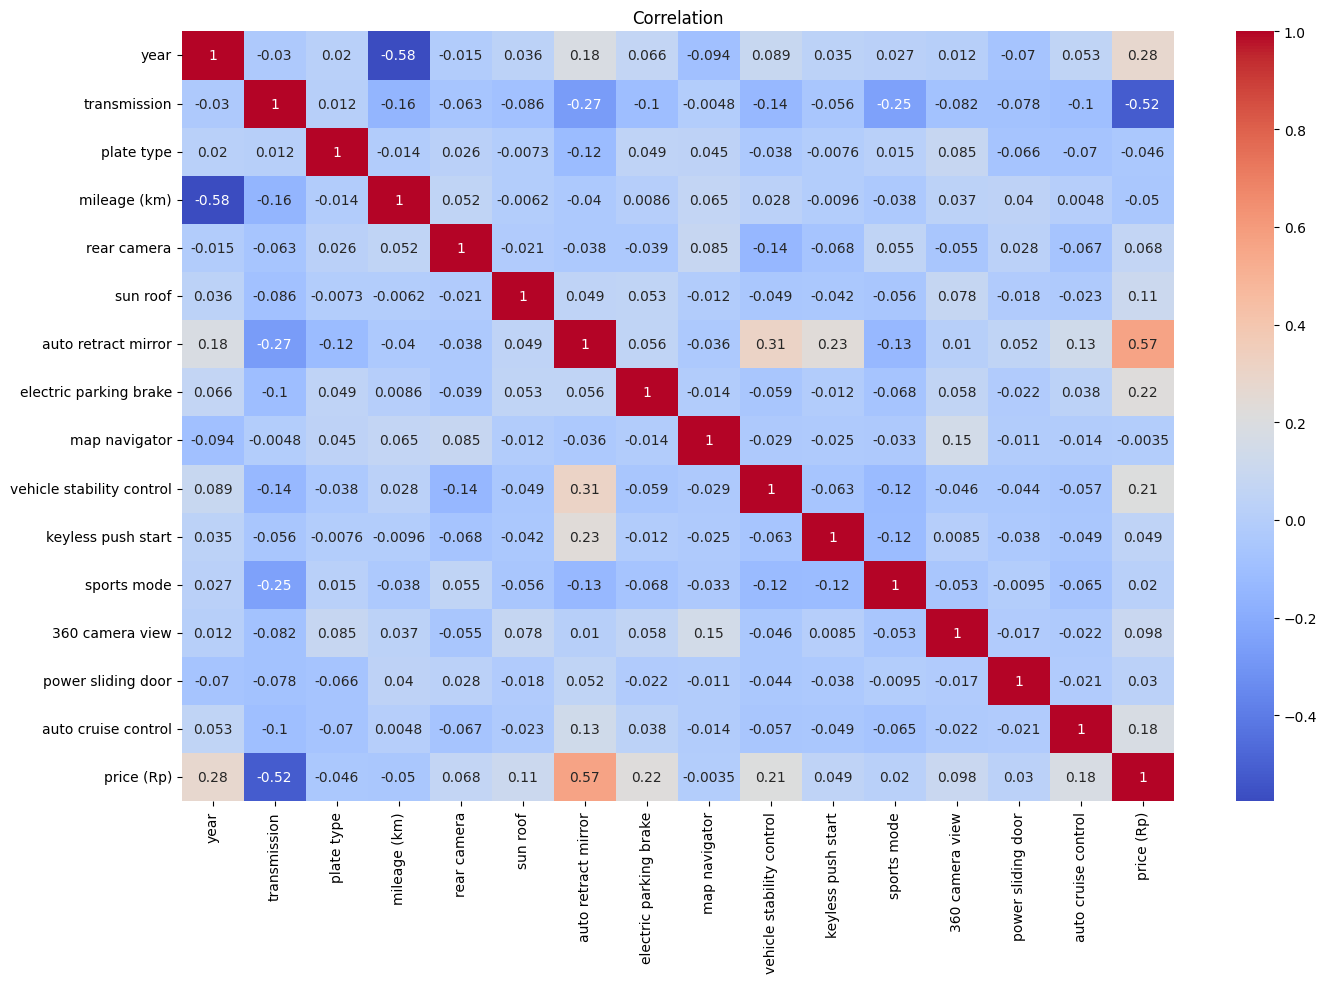

In [48]:
mc =dataset_cadangan[['year','transmission','plate type','mileage (km)', 'rear camera', 'sun roof','auto retract mirror','electric parking brake', 'map navigator','vehicle stability control','keyless push start','sports mode','360 camera view','power sliding door','auto cruise control','price (Rp)']].corr()

plt.figure(figsize = (16,10))
sns.heatmap(mc,cmap = 'coolwarm', annot = True )
plt.title('Correlation')
plt.show()

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

spare_dataset = dataset_cadangan.copy()
kolom_df_clean_combined = df_clean_combined.select_dtypes(exclude = 'object').columns
spare_dataset_int = spare_dataset[kolom_df_clean_combined]

# Separate features (X) and target (y)
X = spare_dataset_int.drop('price (Rp)', axis=1)
y = spare_dataset_int['price (Rp)']

filter_selection = SelectKBest(f_regression, k = 4)
dframe = filter_selection.fit_transform(X, y)


In [71]:
column_feature = filter_selection.get_feature_names_out()
Data1= pd.DataFrame(dframe, columns=column_feature)
Data1

,year,auto retract mirror,electric parking brake,vehicle stability control
0,2018.0,0.0,0.0,0.0
1,2015.0,0.0,0.0,0.0
2,2019.0,0.0,0.0,0.0
3,2021.0,1.0,0.0,0.0
4,2022.0,1.0,0.0,0.0
...,...,...,...,...
565,2018.0,0.0,0.0,0.0
566,2020.0,1.0,0.0,0.0
567,2021.0,1.0,0.0,0.0
568,2019.0,0.0,0.0,0.0


In [62]:
dataset_cadangan

,car name_0,car name_1,car name_2,car name_3,car name_4,car name_5,car name_6,car name_7,year,mileage (km),...,auto retract mirror,electric parking brake,map navigator,vehicle stability control,keyless push start,sports mode,360 camera view,power sliding door,auto cruise control,price (Rp)
0,0,0,0,0,0,0,0,1,2018,10.508,...,0,0,0,0,0,0,0,0,0,101000000
1,0,0,0,0,0,0,1,0,2015,112.888,...,0,0,0,0,0,0,0,0,0,82000000
2,0,0,0,0,0,0,1,1,2019,30.404,...,0,0,0,0,0,0,0,0,0,117000000
3,0,0,0,0,0,1,0,0,2021,17.306,...,1,0,0,0,0,0,0,0,0,180000000
4,0,0,0,0,0,1,0,1,2022,12.211,...,1,0,0,0,0,0,0,0,0,211000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,0,0,0,0,0,0,1,1,2018,60.588,...,0,0,0,0,0,0,0,0,0,122000000
566,0,0,1,1,0,1,0,1,2020,50.137,...,1,0,0,0,0,0,0,0,0,204000000
567,1,0,0,1,1,1,0,0,2021,32.288,...,1,0,0,0,0,0,0,0,0,234000000
568,0,0,0,0,0,1,1,1,2019,26.474,...,0,0,0,0,0,0,0,0,0,136000000


In [72]:
final_df = dataset_cadangan.copy()
final_df

,car name_0,car name_1,car name_2,car name_3,car name_4,car name_5,car name_6,car name_7,year,mileage (km),...,auto retract mirror,electric parking brake,map navigator,vehicle stability control,keyless push start,sports mode,360 camera view,power sliding door,auto cruise control,price (Rp)
0,0,0,0,0,0,0,0,1,2018,10.508,...,0,0,0,0,0,0,0,0,0,101000000
1,0,0,0,0,0,0,1,0,2015,112.888,...,0,0,0,0,0,0,0,0,0,82000000
2,0,0,0,0,0,0,1,1,2019,30.404,...,0,0,0,0,0,0,0,0,0,117000000
3,0,0,0,0,0,1,0,0,2021,17.306,...,1,0,0,0,0,0,0,0,0,180000000
4,0,0,0,0,0,1,0,1,2022,12.211,...,1,0,0,0,0,0,0,0,0,211000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,0,0,0,0,0,0,1,1,2018,60.588,...,0,0,0,0,0,0,0,0,0,122000000
566,0,0,1,1,0,1,0,1,2020,50.137,...,1,0,0,0,0,0,0,0,0,204000000
567,1,0,0,1,1,1,0,0,2021,32.288,...,1,0,0,0,0,0,0,0,0,234000000
568,0,0,0,0,0,1,1,1,2019,26.474,...,0,0,0,0,0,0,0,0,0,136000000


In [73]:
final_df_1 = final_df.drop(X.columns, axis = 1)
final_df_fix = pd.concat([final_df_1, Data1], axis = 1)

In [79]:
print(final_df_fix.dtypes)

car name_0                     int64
car name_1                     int64
car name_2                     int64
car name_3                     int64
car name_4                     int64
car name_5                     int64
car name_6                     int64
car name_7                     int64
location_0                     int64
location_1                     int64
location_2                     int64
location_3                     int64
transmission                 float64
plate type                   float64
price (Rp)                     int64
year                         float64
auto retract mirror          float64
electric parking brake       float64
vehicle stability control    float64
dtype: object


#Model Training menggunakan beberapa model regresi

Import model serta metric score yang dibutuhkan

In [80]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


x = final_df_fix.drop(['price (Rp)'], axis = 1)
y = final_df_fix['price (Rp)']
x_test, x_train, y_test, y_train = train_test_split(x,y, test_size = 0.3, random_state = 42)


In [69]:
#Membuat fungsi untuk menampilkan metric evaluasi
def eval_score (y_train,y_test, train_pred, test_pred, *, model_regressor : str) :
  mae_train = mean_absolute_error(y_train, train_pred)
  mse_train = mean_squared_error(y_train, train_pred)
  r2_train = r2_score(y_train, train_pred)

  mae_test = mean_absolute_error(y_test, test_pred)
  mse_test = mean_squared_error(y_test, test_pred)
  r2_test= r2_score(y_test, test_pred)

  return {'regressor' : model_regressor,
          'mae_score (train)' : mae_train,
          'mae_score (test)' : mae_test,
          'mse_score (train)': mse_train,
          'mse_score (test)': mse_test,
          'r2_score (train)' : r2_train,
          'r2_score (test)' : r2_test}

##Train menggunakan model SVR

In [90]:
#membentuk model menggunakan pipeline dan wrapper
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.svm import SVR
transform_scaler = ColumnTransformer([("num", StandardScaler(), ['year'])], remainder='passthrough')
model_svr = TransformedTargetRegressor(SVR(), transformer = StandardScaler())
SVR = Pipeline(steps = [('prepro', transform_scaler), ('model', model_svr)])

#SVR model training
SVR.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prepro',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['year'])])),
                ('model',
                 TransformedTargetRegressor(regressor=SVR(),
                                            transformer=StandardScaler()))])

In [91]:
#Prediksi
svr_train_prediction = SVR.predict(x_train)
svr_test_prediction = SVR.predict(x_test)

In [92]:
SVR_score = eval_score(y_train, y_test, svr_train_prediction, svr_test_prediction, model_regressor = 'SVR')
df_svr = pd.DataFrame(SVR_score, index =[1])
df_svr

,regressor,mae_score (train),mae_score (test),mse_score (train),mse_score (test),r2_score (train),r2_score (test)
1,SVR,1.119355e+07,2.185846e+07,3.818700e+14,8.926934e+14,0.852965,0.58856


##Training model menggunakan AdaBoost

In [93]:
#AdaBoost model training
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
adaboost = AdaBoostRegressor(estimator=ExtraTreesRegressor(bootstrap = True,max_depth = 5), n_estimators=100, learning_rate=0.8)
adaboost.fit(x_train, y_train)


AdaBoostRegressor(estimator=ExtraTreesRegressor(bootstrap=True, max_depth=5),
                  learning_rate=0.8, n_estimators=100)

In [ ]:
adaboost.get_params()

{'estimator__bootstrap': True,
 'estimator__ccp_alpha': 0.0,
 'estimator__criterion': 'squared_error',
 'estimator__max_depth': 5,
 'estimator__max_features': 1.0,
 'estimator__max_leaf_nodes': None,
 'estimator__max_samples': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': None,
 'estimator__oob_score': False,
 'estimator__random_state': None,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'estimator': ExtraTreesRegressor(bootstrap=True, max_depth=5),
 'learning_rate': 0.8,
 'loss': 'linear',
 'n_estimators': 100,
 'random_state': None}

In [94]:
#Prediksi menggunakan model adaboost
adaboost_train_prediction = adaboost.predict(x_train)
adaboost_test_prediction = adaboost.predict(x_test)

In [95]:
adaboost_eval_score = eval_score(y_train, y_test, adaboost_train_prediction, adaboost_test_prediction, model_regressor = 'AdaBoost')
df_adaboost = pd.DataFrame(adaboost_eval_score,index = [1])
df_adaboost

,regressor,mae_score (train),mae_score (test),mse_score (train),mse_score (test),r2_score (train),r2_score (test)
1,AdaBoost,1.378988e+07,2.585045e+07,2.196032e+14,1.029530e+15,0.915444,0.525492


##Training Model menggunakan Linear Regression

In [98]:
#Linear Regression model training
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
regressor_LR = make_pipeline(MinMaxScaler(), LinearRegression())
model_LR = TransformedTargetRegressor(regressor_LR, transformer =MinMaxScaler())

#Linear Regression Training
model_LR.fit(x_train, y_train)

TransformedTargetRegressor(regressor=Pipeline(steps=[('minmaxscaler',
                                                      MinMaxScaler()),
                                                     ('linearregression',
                                                      LinearRegression())]),
                           transformer=MinMaxScaler())

In [99]:
#Prediksi menggunakan LR
LR_train_prediction = model_LR.predict(x_train)
LR_test_prediction = model_LR.predict(x_test)

In [100]:
LR_eval_score = eval_score(y_train, y_test, LR_train_prediction, LR_test_prediction, model_regressor = 'Linear Regression')
df_LR = pd.DataFrame(LR_eval_score, index = [1])
df_LR

,regressor,mae_score (train),mae_score (test),mse_score (train),mse_score (test),r2_score (train),r2_score (test)
1,Linear Regression,2.487530e+07,2.476940e+07,9.846015e+14,9.695721e+14,0.620889,0.553126


##Training Model menggunakan ExtraTree

In [101]:
#ExtraTreeRegressor model
from sklearn.ensemble import ExtraTreesRegressor
model_ET = ExtraTreesRegressor(bootstrap = True,max_depth = 5)

#ET training model
model_ET.fit(x_train, y_train)

ExtraTreesRegressor(bootstrap=True, max_depth=5)

In [102]:
#Prediksi ET
ET_train_prediction = model_ET.predict(x_train)
ET_test_prediction = model_ET.predict(x_test)


In [103]:
ET_eval_score = eval_score(y_train, y_test, ET_train_prediction, ET_test_prediction, model_regressor = 'Extra Trees')
df_ET = pd.DataFrame(ET_eval_score,index = [1])
df_ET

,regressor,mae_score (train),mae_score (test),mse_score (train),mse_score (test),r2_score (train),r2_score (test)
1,Extra Trees,1.532805e+07,2.449794e+07,3.962144e+14,1.018674e+15,0.847442,0.530495


##Model Training menggunakan KNN

In [104]:
#KNN model
from sklearn.neighbors import KNeighborsRegressor
regressor_KNN = make_pipeline(MinMaxScaler(), KNeighborsRegressor())
model_KNN = TransformedTargetRegressor(regressor_KNN, transformer = MinMaxScaler())

#KNN Training
model_KNN.fit(x_train, y_train)


TransformedTargetRegressor(regressor=Pipeline(steps=[('minmaxscaler',
                                                      MinMaxScaler()),
                                                     ('kneighborsregressor',
                                                      KNeighborsRegressor())]),
                           transformer=MinMaxScaler())

In [105]:
#Prediksi KNN
KNN_train_prediction = model_KNN.predict(x_train)
KNN_test_prediction = model_KNN.predict(x_test)

In [106]:
KNN_eval_score = eval_score(y_train, y_test, KNN_train_prediction, KNN_test_prediction, model_regressor = 'KNN')
df_KNN = pd.DataFrame(KNN_eval_score, index = [1])
df_KNN


,regressor,mae_score (train),mae_score (test),mse_score (train),mse_score (test),r2_score (train),r2_score (test)
1,KNN,2.204561e+07,2.409474e+07,9.015391e+14,9.920806e+14,0.652872,0.542752


#Nilai Evaluasi dari setiap model

In [108]:
metrics =pd.concat([df_svr,df_adaboost, df_KNN,df_ET, df_LR])
metrics.reset_index(drop = True, inplace= True)
metrics

,regressor,mae_score (train),mae_score (test),mse_score (train),mse_score (test),r2_score (train),r2_score (test)
0,SVR,1.119355e+07,2.185846e+07,3.818700e+14,8.926934e+14,0.852965,0.588560
1,AdaBoost,1.378988e+07,2.585045e+07,2.196032e+14,1.029530e+15,0.915444,0.525492
2,KNN,2.204561e+07,2.409474e+07,9.015391e+14,9.920806e+14,0.652872,0.542752
3,Extra Trees,1.532805e+07,2.449794e+07,3.962144e+14,1.018674e+15,0.847442,0.530495
4,Linear Regression,2.487530e+07,2.476940e+07,9.846015e+14,9.695721e+14,0.620889,0.553126


In [109]:
display(metrics)

,regressor,mae_score (train),mae_score (test),mse_score (train),mse_score (test),r2_score (train),r2_score (test)
0,SVR,1.119355e+07,2.185846e+07,3.818700e+14,8.926934e+14,0.852965,0.588560
1,AdaBoost,1.378988e+07,2.585045e+07,2.196032e+14,1.029530e+15,0.915444,0.525492
2,KNN,2.204561e+07,2.409474e+07,9.015391e+14,9.920806e+14,0.652872,0.542752
3,Extra Trees,1.532805e+07,2.449794e+07,3.962144e+14,1.018674e+15,0.847442,0.530495
4,Linear Regression,2.487530e+07,2.476940e+07,9.846015e+14,9.695721e+14,0.620889,0.553126


#Export model dan app.py

In [110]:
import pickle

# Save the trained linear_model to a file using pickle
with open('SVR.pkl', 'wb') as file:
    pickle.dump(model_svr, file)

print("SVR model saved to SVR.pkl using pickle.")

SVR model saved to SVR.pkl using pickle.


In [111]:
import pkg_resources

# Get a list of installed packages and their versions
installed_packages = {d.project_name: d.version for d in pkg_resources.working_set}

# Define the packages used in this notebook that should be in requirements.txt
required_packages = [
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn'
]

# Create requirements.txt content
requirements_content = []
for pkg in required_packages:
    if pkg in installed_packages:
        requirements_content.append(f"{pkg}=={installed_packages[pkg]}")
    else:
        # Fallback if package is not found for some reason, though it should be if used
        requirements_content.append(f"{pkg}")

# Write to requirements.txt file
with open('requirements.txt', 'w') as f:
    for item in requirements_content:
        f.write(f"{item}\n")

print("requirements.txt created successfully.")

/tmp/ipykernel_644/2500581109.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


requirements.txt created successfully.


In [ ]:
app_py_content= '''
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Konfigurasi Halaman
st.set_page_config(
    page_title="Prediksi Harga Mobil Bekas",
    page_icon="🚗",
    layout="centered"
)

# --- FUNGSI LOAD DATA & MODEL ---
@st.cache_resource
def load_model():
    """Memuat model Machine Learning yang sudah dilatih"""
    try:
        with open('SVR.pkl', 'rb') as file:
            model = pickle.load(file)
        return model
    except Exception as e:
        st.error(f"Gagal memuat model: {e}")
        return None

@st.cache_data
def load_car_names():
    """Memuat daftar nama mobil dan mapping ID-nya"""
    try:
        # Membaca file Car Model ID.csv
        df = pd.read_csv('Car Model ID.csv')

        # Asumsi: File ini berisi kolom 'Jenis mobil' atau sejenisnya.
        # Kita akan membuat dictionary: {Nama Mobil: ID}
        # ID diasumsikan berdasarkan index baris + 1 (atau sesuai format training Anda)
        # Jika training dimulai dari 0, hapus '+ 1'. Mari kita default ke index (0-based) atau (1-based)
        # Berdasarkan dataset umum, ID seringkali dimulai dari integer tertentu.
        # Disini kita mapping index dataframe ke Nama.

        car_dict = {row[0]: idx for idx, row in df.iterrows()}
        return car_dict
    except Exception as e:
        st.error(f"Gagal memuat daftar mobil: {e}")
        return {}

# --- LOAD RESOURCES ---
model = load_model()
car_map = load_car_names()

# --- UI HEADER ---
st.title("🚗 Aplikasi Prediksi Harga Mobil")
st.markdown("""
Aplikasi ini menggunakan algoritma **SVRt** untuk memprediksi harga pasaran mobil bekas
berdasarkan spesifikasi dan fitur yang dimiliki.
""")
st.divider()

# --- FORM INPUT USER ---
with st.form("prediction_form"):
    st.subheader("Spesifikasi Mobil")

    col1, col2 = st.columns(2)

    with col1:
        # Input Nama Mobil
        # Mengambil list nama mobil dari mapping yang sudah di-load
        car_name_options = list(car_map.keys()) if car_map else ["Data Kosong"]
        selected_car_name = st.selectbox("Pilih Model Mobil", car_name_options)

        # Input Tahun
        year = st.number_input("Tahun Pembuatan", min_value=2000, max_value=2025, value=2018, step=1)

    with col2:
        # Input Transmisi
        # Perlu dipastikan encoding saat training.
        # Umumnya: 1 = Automatic, 0 = Manual (atau sebaliknya).
        # Di sini saya asumsikan 1 = Automatic, 0 = Manual.
        transmission_option = st.radio("Transmisi", ["Manual", "Automatic"])
        transmission = 0 if transmission_option == "Automatic" else 1

    st.subheader("Fitur Tambahan")
    st.caption("Centang fitur yang tersedia pada mobil:")

    c1, c2, c3 = st.columns(3)

    with c1:
        sunroof = st.checkbox("Sun Roof")
        auto_retract = st.checkbox("Auto Retract Mirror")

    with c2:
        electric_parking = st.checkbox("Electric Parking Brake")
        vehicle_stability = st.checkbox("Vehicle Stability Control")

    with c3:
        auto_cruise = st.checkbox("Auto Cruise Control")

    # Tombol Submit
    submitted = st.form_submit_button("🔍 Prediksi Harga", use_container_width=True)

# --- LOGIKA PREDIKSI ---
if submitted:
    if model is None:
        st.error("Model belum dimuat, tidak bisa melakukan prediksi.")
    elif not car_map:
        st.error("Data mapping mobil kosong.")
    else:
        # 1. Konversi Input ke Format Model
        # Mendapatkan ID mobil dari nama yang dipilih
        car_id = car_map[selected_car_name]

        # Konversi boolean ke int (0/1)
        feat_sunroof = 1 if sunroof else 0
        feat_retract = 1 if auto_retract else 0
        feat_electric = 1 if electric_parking else 0
        feat_vsc = 1 if vehicle_stability else 0
        feat_cruise = 1 if auto_cruise else 0

        # Urutan fitur HARUS SAMA PERSIS dengan saat training model (X_train)
        # Berdasarkan file pkl: ['year', 'car name', 'transmission', 'sun roof', 'auto retract mirror', 'electric parking brake', 'vehicle stability control', 'auto cruise control']

        input_data = np.array([[
            year,
            car_id,
            transmission,
            feat_sunroof,
            feat_retract,
            feat_electric,
            feat_vsc,
            feat_cruise
        ]])

        # 2. Lakukan Prediksi
        try:
            predicted_price = model.predict(input_data)[0]

            # 3. Tampilkan Hasil
            st.success("Prediksi Selesai!")
            st.metric(
                label="Estimasi Harga Jual",
                value=f"Rp {int(predicted_price):,.0f}".replace(",", ".")
            )
            st.info("Catatan: Harga ini adalah estimasi berdasarkan data historis. Kondisi fisik aktual mobil dapat mempengaruhi harga nyata.")

        except Exception as e:
            st.error(f"Terjadi kesalahan saat memprediksi: {e}")

# --- SIDEBAR (Optional) ---
st.sidebar.header("Tentang Aplikasi")
st.sidebar.info("Dibuat menggunakan Python & Streamlit dengan model Machine Learning Support Vector Regression.")'''

with open('app.py', 'w') as f:
    f.write(app_py_content)

print("app.py created successfully.")

app.py created successfully.


#Coba-coba

In [ ]:
#import numpy as np
#interval = list(range(1,101))
#ET_score = pd.DataFrame(columns=['mae_score (train)','mae_score (test)','mse_score (train)','mse_score (test)','r2_score (train)','r2_score (test)'])
#for maxdepth in interval :
#  model_ET = ExtraTreesRegressor(max_depth = maxdepth)
#  model_ET.fit(x_train, y_train)
#  y_pred_train = model_ET.predict(x_train)
#  y_pred_test = model_ET.predict(x_test)
#  score = eval_score(y_train, y_test, y_pred_train, y_pred_test, model_regressor = 'Extra Trees')
#  ET_score = pd.concat([ET_score, pd.DataFrame([score])], ignore_index=True) # Corrected: wrapped score in a list
#ET_score

In [ ]:
# @title
#int_learning_rate = np.linspace(0.001,10,100) # Changed start from 0 to 0.001
#adaboost_score = pd.DataFrame(columns=['mae_score (train)','mae_score (test)','mse_score (train)','mse_score (test)','r2_score (train)','r2_score (test)'])
#for lr in int_learning_rate :
#  model_adaboost = AdaBoostRegressor(estimator=ExtraTreesRegressor(bootstrap = True,max_depth = 5), n_estimators=100, learning_rate =lr)
#  model_adaboost.fit(x_train, y_train)
#  y_pred_train_adaboost = model_adaboost.predict(x_train)
#  y_pred_test_adaboost = model_adaboost.predict(x_test)
#  score = eval_score(y_train, y_test, y_pred_train_adaboost, y_pred_test_adaboost, model_regressor = 'Adaboost')
#  adaboost_score = pd.concat([adaboost_score, pd.DataFrame([score])], ignore_index=True) # Corrected DataFrame concatenation, wrapping score in a list for pd.DataFrame
#adaboost_score

In [ ]:
# @title
#adaboost_score[['r2_score (train)','r2_score (test)']] = adaboost_score[['r2_score (train)','r2_score (test)']].astype(float)